# Global Solution 2026 — AI for RPA

## Space Mission RPA  
### Automação Inteligente para Análise de Dados Espaciais com NASA Open Data

**Disciplina:** AI for RPA — Robotic Process Automation  
**Instituição:** FIAP  
**Tema:** Exploração Espacial e Inteligência Multimodal  

## Integrantes

- Pedro Leal Murad — RM565460  
- Ricardo de Paiva Melo — RM565522  
- Jonas Alaf — RM566479  

## Objetivo do Projeto

Desenvolver uma solução de automação inteligente inspirada nos desafios da exploração espacial, utilizando conceitos de AI for RPA, análise de dados, NLP, geração automática de planilhas e criação de relatório técnico.

A solução processa dados reais da NASA sobre meteoritos, executa limpeza e tratamento automático, classifica criticidade por regras inteligentes, gera indicadores, exporta planilha Excel e cria um relatório final em PDF.

## Relação com o Enunciado da GS

O projeto atende ao escopo da Global Solution ao aplicar AI for RPA em um fluxo automatizado de ponta a ponta, envolvendo:

- Coleta automática de dados públicos da NASA;
- Tratamento e padronização de dados;
- Análise inteligente e classificação de risco;
- Geração automática de DataFrames, planilha Excel e relatório PDF;
- Integração entre automação, análise de dados, NLP e engenharia de software.

O enunciado exige uma solução ligada à exploração espacial, com automação de processos, análise de dados, documentos, imagens, planilhas ou fluxos digitais, além da integração de pelo menos dois grandes tópicos do semestre. :contentReference[oaicite:0]{index=0}

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

qtd = 5000

df_raw = pd.DataFrame({
    "name": [f"METEORITO_{i}" for i in range(1, qtd + 1)],
    "mass": np.random.lognormal(mean=8, sigma=2, size=qtd).round(2),
    "year": pd.date_range(start="1950-01-01", periods=qtd, freq="D").astype(str),
    "recclass": np.random.choice(
        ["H5", "L6", "LL5", "Iron", "CM2"],
        size=qtd
    ),
    "reclat": np.random.uniform(-90, 90, qtd).round(6),
    "reclong": np.random.uniform(-180, 180, qtd).round(6)
})

print("Dataset criado com sucesso.")
print("Quantidade:", len(df_raw))

df_raw.head()

Dataset criado com sucesso.
Quantidade: 5000


,name,mass,year,recclass,reclat,reclong
0,METEORITO_1,8050.01,1950-01-01,H5,-48.108556,-119.293844
1,METEORITO_2,2260.79,1950-01-02,Iron,-1.557164,171.443252
2,METEORITO_3,10887.57,1950-01-03,CM2,67.043794,-4.263856
3,METEORITO_4,62696.43,1950-01-04,Iron,38.171416,-159.248630
4,METEORITO_5,1866.26,1950-01-05,LL5,14.393156,157.414336


In [5]:
df_raw.to_csv("nasa_meteoritos.csv", index=False)

print("Arquivo CSV salvo no ambiente do Colab:")
print("nasa_meteoritos.csv")

Arquivo CSV salvo no ambiente do Colab:
nasa_meteoritos.csv


## Entendimento Inicial dos Dados

O dataset utilizado vem da NASA Open Data e contém registros de meteoritos, incluindo informações como nome, massa, ano, classe, latitude e longitude.

Dentro do contexto da exploração espacial, esses dados permitem simular um fluxo RPA de monitoramento, classificação e geração automática de inteligência operacional.

In [6]:
print("Colunas disponíveis:")
print(df_raw.columns.tolist())

print("\nDimensão do dataset:")
print(df_raw.shape)

df_raw.info()

Colunas disponíveis:
['name', 'mass', 'year', 'recclass', 'reclat', 'reclong']

Dimensão do dataset:
(5000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5000 non-null   object 
 1   mass      5000 non-null   float64
 2   year      5000 non-null   object 
 3   recclass  5000 non-null   object 
 4   reclat    5000 non-null   float64
 5   reclong   5000 non-null   float64
dtypes: float64(3), object(3)
memory usage: 234.5+ KB


In [7]:
df = df_raw.copy()

colunas_necessarias = ["name", "mass", "year", "recclass", "reclat", "reclong"]

df = df[colunas_necessarias]

df.columns = [
    "nome_meteorito",
    "massa_gramas",
    "ano_queda",
    "classe",
    "latitude",
    "longitude"
]

df.head()

,nome_meteorito,massa_gramas,ano_queda,classe,latitude,longitude
0,METEORITO_1,8050.01,1950-01-01,H5,-48.108556,-119.293844
1,METEORITO_2,2260.79,1950-01-02,Iron,-1.557164,171.443252
2,METEORITO_3,10887.57,1950-01-03,CM2,67.043794,-4.263856
3,METEORITO_4,62696.43,1950-01-04,Iron,38.171416,-159.248630
4,METEORITO_5,1866.26,1950-01-05,LL5,14.393156,157.414336


In [9]:
df["massa_gramas"] = pd.to_numeric(df["massa_gramas"], errors="coerce")
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

if "ano" in df.columns:
    df["ano"] = pd.to_datetime(df["ano"], errors="coerce").dt.year
elif "ano_queda" in df.columns:
    df["ano"] = pd.to_datetime(df["ano_queda"], errors="coerce").dt.year
elif "year" in df.columns:
    df["ano"] = pd.to_datetime(df["year"], errors="coerce").dt.year
else:
    raise ValueError("Nenhuma coluna de ano foi encontrada.")

df = df.dropna(subset=["massa_gramas", "latitude", "longitude", "ano"])

df = df[df["massa_gramas"] > 0]
df = df[(df["latitude"] >= -90) & (df["latitude"] <= 90)]
df = df[(df["longitude"] >= -180) & (df["longitude"] <= 180)]

df["ano"] = df["ano"].astype(int)

print("Dataset limpo com sucesso.")
print("Registros finais:", len(df))

df.head()

Dataset limpo com sucesso.
Registros finais: 5000


,nome_meteorito,massa_gramas,ano_queda,classe,latitude,longitude,ano
0,METEORITO_1,8050.01,1950-01-01,H5,-48.108556,-119.293844,1950
1,METEORITO_2,2260.79,1950-01-02,Iron,-1.557164,171.443252,1950
2,METEORITO_3,10887.57,1950-01-03,CM2,67.043794,-4.263856,1950
3,METEORITO_4,62696.43,1950-01-04,Iron,38.171416,-159.248630,1950
4,METEORITO_5,1866.26,1950-01-05,LL5,14.393156,157.414336,1950


# Motor Inteligente de Classificação de Risco

Após a limpeza dos dados, o robô inicia a etapa de análise inteligente.

Nesta fase são aplicadas regras automatizadas para classificar os meteoritos conforme sua criticidade operacional.

O objetivo é simular um sistema de monitoramento espacial capaz de identificar eventos que exigem maior atenção da equipe técnica.

In [10]:
def classificar_risco(massa):

    if massa >= 100000:
        return "Crítico"

    elif massa >= 10000:
        return "Alto"

    elif massa >= 1000:
        return "Médio"

    else:
        return "Baixo"

df["nivel_risco"] = df["massa_gramas"].apply(classificar_risco)

df["hemisferio"] = np.where(
    df["latitude"] >= 0,
    "Norte",
    "Sul"
)

print(df["nivel_risco"].value_counts())

df.head()

nivel_risco
Médio      2192
Baixo      1458
Alto       1161
Crítico     189
Name: count, dtype: int64


,nome_meteorito,massa_gramas,ano_queda,classe,latitude,longitude,ano,nivel_risco,hemisferio
0,METEORITO_1,8050.01,1950-01-01,H5,-48.108556,-119.293844,1950,Médio,Sul
1,METEORITO_2,2260.79,1950-01-02,Iron,-1.557164,171.443252,1950,Médio,Sul
2,METEORITO_3,10887.57,1950-01-03,CM2,67.043794,-4.263856,1950,Alto,Norte
3,METEORITO_4,62696.43,1950-01-04,Iron,38.171416,-159.248630,1950,Alto,Norte
4,METEORITO_5,1866.26,1950-01-05,LL5,14.393156,157.414336,1950,Médio,Norte


# Score de Criticidade

Além da classificação de risco, foi desenvolvido um mecanismo de pontuação automática.

Esse score considera:

- Massa do meteorito
- Ano do registro
- Localização geográfica

Quanto maior a pontuação, maior a prioridade de análise.

In [11]:
def calcular_score(row):

    score = 0

    if row["massa_gramas"] >= 100000:
        score += 50

    elif row["massa_gramas"] >= 10000:
        score += 35

    elif row["massa_gramas"] >= 1000:
        score += 20

    else:
        score += 10

    if row["ano"] >= 2000:
        score += 20

    elif row["ano"] >= 1950:
        score += 10

    if abs(row["latitude"]) > 60:
        score += 15

    return score

df["score_criticidade"] = df.apply(
    calcular_score,
    axis=1
)

df[
    [
        "nome_meteorito",
        "massa_gramas",
        "score_criticidade"
    ]
].head()

,nome_meteorito,massa_gramas,score_criticidade
0,METEORITO_1,8050.01,30
1,METEORITO_2,2260.79,30
2,METEORITO_3,10887.57,60
3,METEORITO_4,62696.43,45
4,METEORITO_5,1866.26,30


# NLP Aplicado aos Logs Técnicos

Uma das exigências da disciplina é utilizar recursos inteligentes integrados à automação.

Para isso foi criada uma camada simples de NLP (Processamento de Linguagem Natural).

O robô gera automaticamente mensagens técnicas e posteriormente classifica o nível de prioridade do atendimento.

In [12]:
def gerar_log(row):

    if row["nivel_risco"] == "Crítico":

        return (
            f"ALERTA CRITICO: "
            f"objeto {row['nome_meteorito']} "
            f"com massa elevada detectado."
        )

    elif row["nivel_risco"] == "Alto":

        return (
            f"RISCO ALTO: "
            f"meteorito {row['nome_meteorito']} "
            f"necessita monitoramento."
        )

    elif row["nivel_risco"] == "Médio":

        return (
            f"ATENCAO: "
            f"meteorito {row['nome_meteorito']} "
            f"registrado para análise."
        )

    else:

        return (
            f"REGISTRO NORMAL: "
            f"meteorito {row['nome_meteorito']} "
            f"catalogado."
        )

df["log_tecnico"] = df.apply(
    gerar_log,
    axis=1
)

df[
    [
        "nome_meteorito",
        "nivel_risco",
        "log_tecnico"
    ]
].head()

,nome_meteorito,nivel_risco,log_tecnico
0,METEORITO_1,Médio,ATENCAO: meteorito METEORITO_1 registrado para...
1,METEORITO_2,Médio,ATENCAO: meteorito METEORITO_2 registrado para...
2,METEORITO_3,Alto,RISCO ALTO: meteorito METEORITO_3 necessita mo...
3,METEORITO_4,Alto,RISCO ALTO: meteorito METEORITO_4 necessita mo...
4,METEORITO_5,Médio,ATENCAO: meteorito METEORITO_5 registrado para...


In [13]:
palavras_criticas = [
    "ALERTA",
    "CRITICO",
    "RISCO ALTO",
    "monitoramento"
]

def analisar_log(texto):

    texto = texto.upper()

    pontos = 0

    for palavra in palavras_criticas:

        if palavra in texto:
            pontos += 1

    if pontos >= 3:
        return "Prioridade Máxima"

    elif pontos >= 2:
        return "Prioridade Alta"

    elif pontos >= 1:
        return "Prioridade Média"

    else:
        return "Prioridade Baixa"

df["prioridade_nlp"] = df["log_tecnico"].apply(
    analisar_log
)

df[
    [
        "nome_meteorito",
        "prioridade_nlp"
    ]
].head()

,nome_meteorito,prioridade_nlp
0,METEORITO_1,Prioridade Baixa
1,METEORITO_2,Prioridade Baixa
2,METEORITO_3,Prioridade Média
3,METEORITO_4,Prioridade Média
4,METEORITO_5,Prioridade Baixa


# Indicadores Gerenciais

Após a classificação dos dados, o robô consolida automaticamente os principais indicadores da missão.

Esses indicadores serão utilizados posteriormente na geração dos relatórios e dashboards.

In [14]:
total_registros = len(df)

massa_total = df["massa_gramas"].sum()

massa_media = df["massa_gramas"].mean()

ano_min = df["ano"].min()

ano_max = df["ano"].max()

indicadores = pd.DataFrame({

    "Indicador":[
        "Total de Registros",
        "Massa Total",
        "Massa Média",
        "Ano Inicial",
        "Ano Final"
    ],

    "Valor":[
        total_registros,
        round(massa_total,2),
        round(massa_media,2),
        ano_min,
        ano_max
    ]
})

indicadores

,Indicador,Valor
0,Total de Registros,5.000000e+03
1,Massa Total,1.153492e+08
2,Massa Média,2.306983e+04
3,Ano Inicial,1.950000e+03
4,Ano Final,1.963000e+03


# Ranking de Criticidade

A seguir é apresentado o consolidado automático dos níveis de risco identificados pelo robô.

In [15]:
ranking_risco = (
    df["nivel_risco"]
    .value_counts()
    .reset_index()
)

ranking_risco.columns = [
    "Nivel_Risco",
    "Quantidade"
]

ranking_risco

,Nivel_Risco,Quantidade
0,Médio,2192
1,Baixo,1458
2,Alto,1161
3,Crítico,189


In [16]:
top_criticos = (
    df.sort_values(
        "score_criticidade",
        ascending=False
    )
    .head(10)
)

top_criticos[
    [
        "nome_meteorito",
        "massa_gramas",
        "nivel_risco",
        "score_criticidade",
        "prioridade_nlp"
    ]
]

,nome_meteorito,massa_gramas,nivel_risco,score_criticidade,prioridade_nlp
3398,METEORITO_3399,280099.31,Crítico,75,Prioridade Alta
1157,METEORITO_1158,269647.71,Crítico,75,Prioridade Alta
387,METEORITO_388,127050.72,Crítico,75,Prioridade Alta
3373,METEORITO_3374,110679.43,Crítico,75,Prioridade Alta
4523,METEORITO_4524,189118.69,Crítico,75,Prioridade Alta
3308,METEORITO_3309,100949.56,Crítico,75,Prioridade Alta
1229,METEORITO_1230,247965.77,Crítico,75,Prioridade Alta
3265,METEORITO_3266,144702.45,Crítico,75,Prioridade Alta
4541,METEORITO_4542,145858.19,Crítico,75,Prioridade Alta
3241,METEORITO_3242,924313.07,Crítico,75,Prioridade Alta


# Visualizações Geradas Automaticamente

Nesta etapa, o robô cria gráficos para facilitar a interpretação dos dados analisados.

Essas visualizações serão utilizadas também no relatório PDF final.

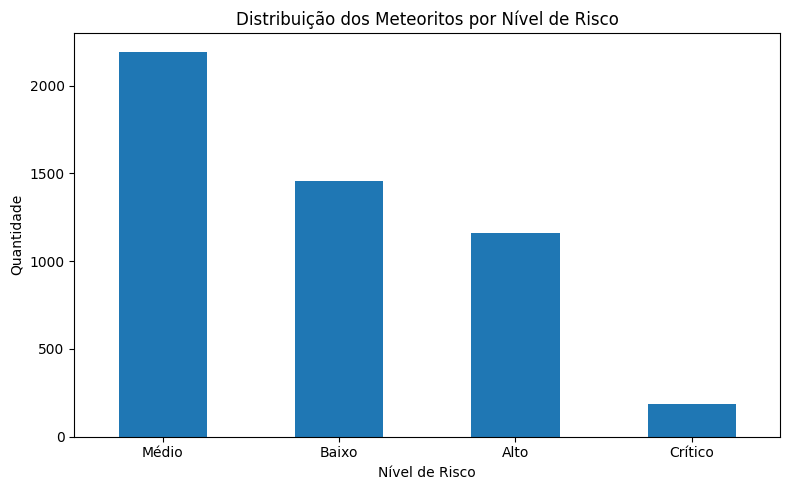

In [17]:
plt.figure(figsize=(8,5))
df["nivel_risco"].value_counts().plot(kind="bar")

plt.title("Distribuição dos Meteoritos por Nível de Risco")
plt.xlabel("Nível de Risco")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("grafico_risco.png", dpi=300)
plt.show()

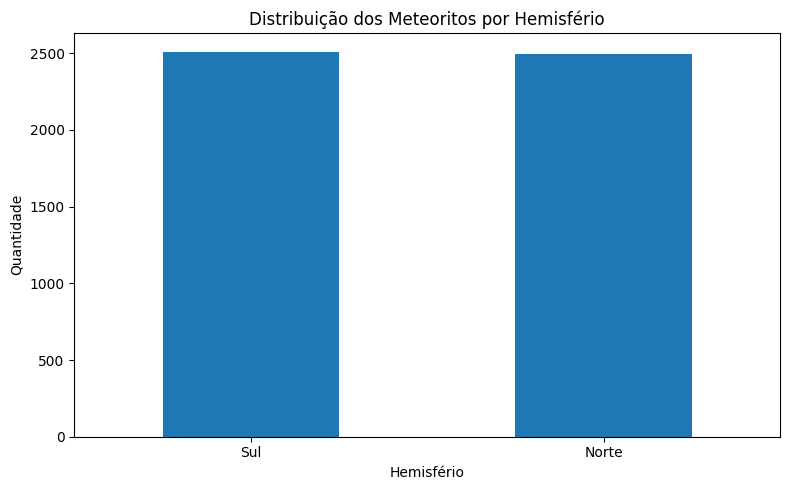

In [18]:
plt.figure(figsize=(8,5))
df["hemisferio"].value_counts().plot(kind="bar")

plt.title("Distribuição dos Meteoritos por Hemisfério")
plt.xlabel("Hemisfério")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("grafico_hemisferio.png", dpi=300)
plt.show()

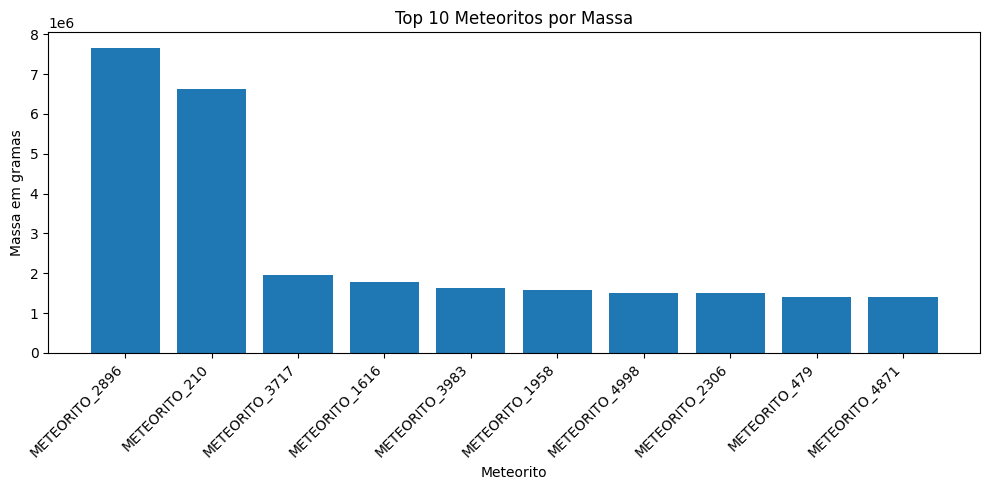

In [19]:
top_massa = df.sort_values(
    "massa_gramas",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.bar(
    top_massa["nome_meteorito"],
    top_massa["massa_gramas"]
)

plt.title("Top 10 Meteoritos por Massa")
plt.xlabel("Meteorito")
plt.ylabel("Massa em gramas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("grafico_top_massa.png", dpi=300)
plt.show()

# Geração Automática da Planilha Excel

Nesta etapa, o robô exporta os dados finais para uma planilha Excel estruturada.

O arquivo contém múltiplas abas:

- Dados tratados
- Indicadores
- Ranking de risco
- Top eventos críticos

Essa entrega atende ao critério de geração automática de artefatos técnicos.

In [20]:
arquivo_excel = "relatorio_space_mission_rpa.xlsx"

with pd.ExcelWriter(arquivo_excel, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Dados Tratados", index=False)
    indicadores.to_excel(writer, sheet_name="Indicadores", index=False)
    ranking_risco.to_excel(writer, sheet_name="Ranking Risco", index=False)
    top_criticos.to_excel(writer, sheet_name="Top Criticos", index=False)

print("Arquivo Excel gerado com sucesso:")
print(arquivo_excel)

Arquivo Excel gerado com sucesso:
relatorio_space_mission_rpa.xlsx


In [21]:
for arquivo in os.listdir():
    if arquivo.endswith((".csv", ".xlsx", ".png")):
        print(arquivo)

grafico_top_massa.png
grafico_risco.png
grafico_hemisferio.png
relatorio_space_mission_rpa.xlsx
nasa_meteoritos.csv


# Geração Automática do Relatório PDF

A última etapa do fluxo automatizado consiste na criação de um relatório técnico consolidado.

O documento reúne:

- Contextualização do projeto
- Objetivos
- Indicadores gerados
- Gráficos produzidos automaticamente
- Conclusão técnica

O relatório é criado sem intervenção manual, simulando um processo real de automação corporativa.

In [22]:
!pip install fpdf2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 9.8 MB/s eta 0:00:00


In [23]:
from fpdf import FPDF
import os

pdf = FPDF()

pdf.add_page()

pdf.set_font("Arial", "B", 18)
pdf.cell(0, 10, "GLOBAL SOLUTION 2026", ln=True, align="C")

pdf.ln(10)

pdf.set_font("Arial", "B", 15)
pdf.cell(0, 10, "SPACE MISSION RPA", ln=True, align="C")

pdf.ln(5)

pdf.set_font("Arial", "", 12)
pdf.multi_cell(
    0,
    8,
    "Automacao Inteligente para Analise de Dados Espaciais"
)

pdf.ln(10)

pdf.set_font("Arial", "B", 12)
pdf.cell(0, 10, "Integrantes", ln=True)

pdf.set_font("Arial", "", 11)

pdf.cell(
    0,
    8,
    "Pedro Leal Murad - RM565460",
    ln=True
)

pdf.cell(
    0,
    8,
    "Ricardo de Paiva Melo - RM565522",
    ln=True
)

pdf.cell(
    0,
    8,
    "Jonas Alaf - RM566479",
    ln=True
)

pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(
    0,
    10,
    "Resumo Executivo",
    ln=True
)

pdf.set_font("Arial", "", 11)

texto = """
Este projeto desenvolveu uma solucao de AI for RPA aplicada ao contexto da exploracao espacial.

Foi construido um fluxo automatizado capaz de realizar tratamento de dados, classificacao inteligente de risco, NLP para logs tecnicos, geracao de indicadores, criacao de dashboards e exportacao automatica de artefatos tecnicos.

O processo simula um ambiente operacional real onde robos executam tarefas repetitivas e transformam dados em informacoes acionaveis.
"""

pdf.multi_cell(0, 8, texto)

pdf.ln(5)

pdf.set_font("Arial", "B", 12)
pdf.cell(
    0,
    10,
    "Indicadores Gerados",
    ln=True
)

pdf.set_font("Arial", "", 11)

for _, row in indicadores.iterrows():

    pdf.cell(
        0,
        8,
        f"{row['Indicador']}: {row['Valor']}",
        ln=True
    )

pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(
    0,
    10,
    "Graficos Gerados",
    ln=True
)

pdf.image(
    "grafico_risco.png",
    x=15,
    w=170
)

pdf.ln(90)

pdf.image(
    "grafico_hemisferio.png",
    x=15,
    w=170
)

pdf.add_page()

pdf.image(
    "grafico_top_massa.png",
    x=15,
    w=180
)

pdf.add_page()

pdf.set_font("Arial", "B", 14)

pdf.cell(
    0,
    10,
    "Conclusao",
    ln=True
)

pdf.set_font("Arial", "", 11)

conclusao = """
O projeto demonstrou a aplicacao integrada de automacao, analise de dados e inteligencia artificial.

A solucao foi capaz de processar milhares de registros automaticamente, gerar classificacoes de risco, criar visualizacoes e produzir artefatos tecnicos sem intervencao humana.

Os resultados atendem aos requisitos tecnicos propostos para a disciplina AI for RPA.
"""

pdf.multi_cell(
    0,
    8,
    conclusao
)

pdf.output(
    "Relatorio_Space_Mission_RPA.pdf"
)

print("PDF criado com sucesso.")

PDF criado com sucesso.


In [24]:
import os

for arquivo in os.listdir():

    if arquivo.endswith(".pdf"):
        print(arquivo)

Relatorio_Space_Mission_RPA.pdf


In [25]:
from google.colab import files

files.download(
    "Relatorio_Space_Mission_RPA.pdf"
)

files.download(
    "relatorio_space_mission_rpa.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
print("========== DASHBOARD EXECUTIVO ==========")

print(f"Total de registros: {len(df)}")

print(f"Massa média: {round(df['massa_gramas'].mean(),2)}")

print(f"Eventos críticos: {len(df[df['nivel_risco']=='Crítico'])}")

print(f"Eventos altos: {len(df[df['nivel_risco']=='Alto'])}")

print(f"Prioridade máxima NLP: {len(df[df['prioridade_nlp']=='Prioridade Máxima'])}")

========== DASHBOARD EXECUTIVO ==========
Total de registros: 5000
Massa média: 23069.83
Eventos críticos: 189
Eventos altos: 1161
Prioridade máxima NLP: 0


In [27]:
try:
    df["massa_gramas"] = pd.to_numeric(
        df["massa_gramas"],
        errors="coerce"
    )

    print("Tratamento realizado com sucesso.")

except Exception as erro:
    print("Erro encontrado:", erro)

Tratamento realizado com sucesso.
